In [1]:
from scipy.interpolate import RectBivariateSpline, interp1d
import numpy as np
from cosmopower import cosmopower_NN
import os
import matplotlib.pyplot as plt
# Plot style
import seaborn as sns
import MGLensing
sns.set_theme(style="ticks")
sns.set_palette(sns.color_palette("Paired"))

from matplotlib import rc
rc('text', usetex=True)
#rc('font',**{'family':'serif','serif':['Times']})
plt.rcParams["text.usetex"] = False
plt.rc('mathtext', fontset='stix')
plt.rc('xtick',labelsize=20)
plt.rc('ytick',labelsize=20)
plt.rc('font',size=20)
plt.rc('axes', titlesize=25)
plt.rc('axes', labelsize=20)
plt.rc('lines', linewidth=3)
plt.rc('lines', markersize=6)
plt.rc('legend', fontsize=18)

2026-04-08 11:09:53.881941: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-08 11:09:54.406986: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-08 11:09:55.003192: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-08 11:09:55.005583: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-08 11:10:03.422947: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Co

euclidlib not installed! Euclid TR1 setup will not be available!
/home/c2042999/MGLensing/MGLensing


In [2]:
emu_ranges_all = {
        'Omega_m':      {'p1':0.2899,            'p2':0.3392}, 
        'Omega_b':      {'p1':0.04044,         'p2':0.05686}, 
        'h':            {'p1':0.6375,           'p2':0.731},
        'ns':           {'p1':0.9432,          'p2':0.9862},
        'As':           {'p1':1.5e-09,         'p2':2.7e-09},
        'Omega_nu':     {'p1':0.,              'p2':0.00317},
        'gamma':       {'p1':0.,              'p2':1.},
        'q1':           {'p1':-5.,             'p2':5.},
        'q2':           {'p1':-5.,             'p2':5.},
        'q3':           {'p1':-5.,             'p2':5.},
}

In [11]:
print('initialising Growth Index Parametrisation')
cp_nl_gamma_model = cosmopower_NN(restore=True, 
                        restore_filename='../emulators/gamma/react_boost_gamma_q123', 
                        )
kh_nl_boost = cp_nl_gamma_model.modes # 0.01..5. h/Mpc 

cp_nl_fr_model = cosmopower_NN(restore=True, 
                        restore_filename='../emulators/fofr/react_boost_fofr',
                        )

cp_nl_ndgp_model = cosmopower_NN(restore=True, 
                        restore_filename='../emulators/ndgp/react_boost_ndgp',
                        )

initialising Growth Index Parametrisation


In [12]:
# sanity check for LCDM limit
def mg_boost_lcdm(q1, q2, q3):
    params_react = {
                'ns'            :  [0.97, 0.97],
                'As'            :  [2.e-09, 2.e-09],
                'H0'            :  [68., 68.],
                'Omega_b'       :  [0.05, 0.05],
                'Omega_m'       :  [0.35, 0.35],  # fixed to LCDM value
                'Omega_nu'      :  [0., 0.],
                'gamma'        :  [0.55, 0.55],  # fixed to LCDM value
                'q1'            :  [q1, q1],
                'q2'            :  [q2, q2],
                'q3'            :  [q3, q3],
                'z'             :  [0., 1.]}

    mg_boost_lcdm = cp_nl_gamma_model.predictions_np(params_react) 
    return mg_boost_lcdm


Text(0, 0.5, 'boost in $\\Lambda$CDM limit')

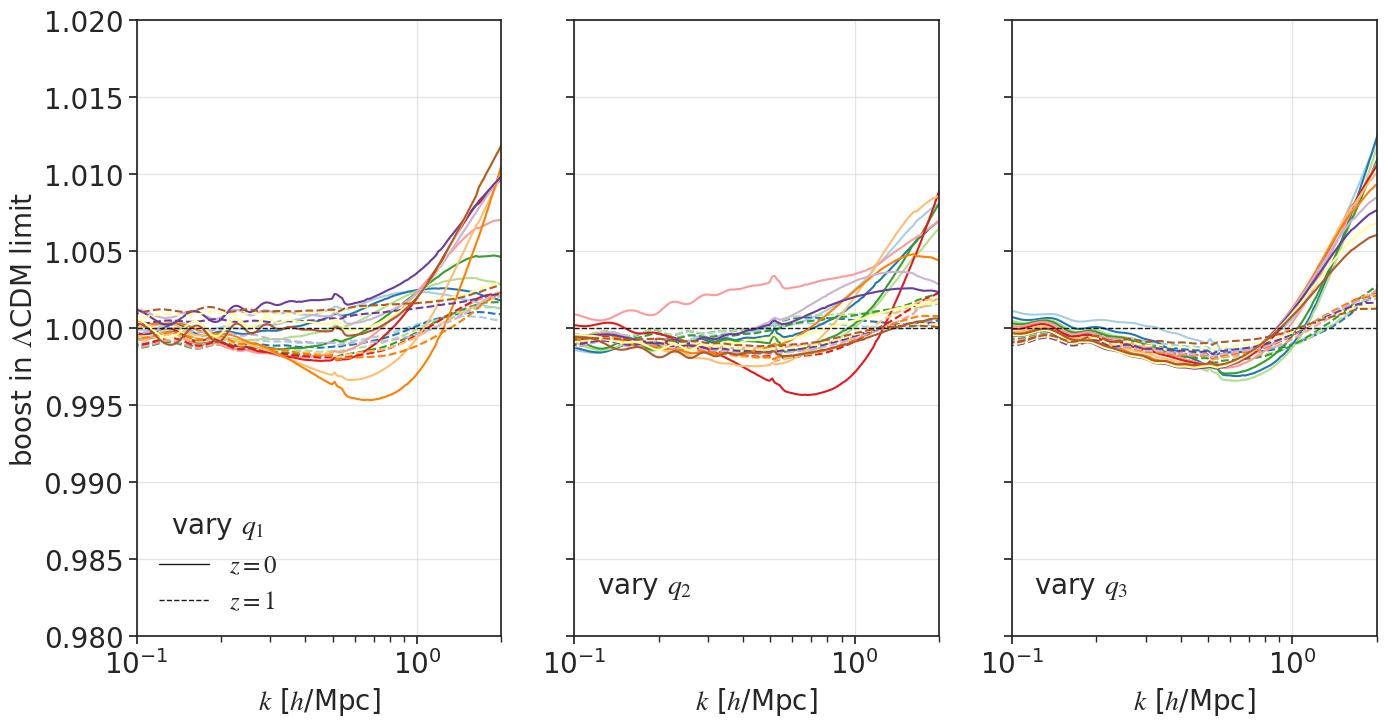

In [13]:
colors = sns.color_palette("Paired")
q_arr = np.linspace(-3, 3, 12)
fig, ax = plt.subplots(1, 3, figsize=(16, 8), facecolor='w', sharex=True, sharey=True)
for j in range(len(q_arr)):    
    boost = mg_boost_lcdm(q_arr[j], 0., 0.)
    ax[0].semilogx(kh_nl_boost, boost[0], linewidth=1.5, color = colors[j], linestyle='-')
    ax[0].semilogx(kh_nl_boost, boost[1], linewidth=1.5, color = colors[j], linestyle='--')

    boost = mg_boost_lcdm(0., q_arr[j], 0.)
    ax[1].semilogx(kh_nl_boost, boost[0], linewidth=1.5, color = colors[j], linestyle='-')
    ax[1].semilogx(kh_nl_boost, boost[1], linewidth=1.5, color = colors[j], linestyle='--')

    boost = mg_boost_lcdm(0., 0., q_arr[j])
    ax[2].semilogx(kh_nl_boost, boost[0], linewidth=1.5, color = colors[j], linestyle='-')
    ax[2].semilogx(kh_nl_boost, boost[1], linewidth=1.5, color = colors[j], linestyle='--')
ax[0].axhline(y=0.5, color='k', linestyle='-', linewidth=1, label="$z=0$")    
ax[0].axhline(y=0.5, color='k', linestyle='--', linewidth=1, label="$z=1$")    
for i in range(3):    
    ax[i].legend(title='vary $q_'+str(i+1)+'$', loc='lower left', frameon=False, title_fontsize=20)
    ax[i].set_xlabel("$k$ [$h$/Mpc]")
    ax[i].grid(alpha=0.5)
    ax[i].grid(alpha=0.5)
    ax[i].set_ylim(0.98, 1.02)    
    ax[i].set_xlim(0.1, 2.)    
    ax[i].axhline(y=1.0, color='k', linestyle='--', linewidth=1)   
ax[0].set_ylabel("boost in $\\Lambda$CDM limit")

In [20]:
def mg_boost_q1q2q3(gamma, q1, q2, q3):
    params_react = {
                'ns'            :  [0.97, 0.97],
                'As'            :  [2.e-09, 2.e-09],
                'H0'            :  [68., 68.],
                'Omega_b'       :  [0.05, 0.05],
                'Omega_m'       :  [0.35, 0.35],  
                'Omega_nu'      :  [0., 0.],
                'gamma'        :  [gamma, gamma],  
                'q1'            :  [q1, q1],
                'q2'            :  [q2, q2],
                'q3'            :  [q3, q3],
                'z'             :  [0., 1.]}

    mg_boost_lcdm = cp_nl_gamma_model.predictions_np(params_react) 
    return mg_boost_lcdm

def mg_boost_fr(fR0):
    params_react = {
                'ns'            :  [0.97, 0.97],
                'As'            :  [2.e-09, 2.e-09],
                'H0'            :  [68., 68.],
                'Omega_b'       :  [0.05, 0.05],
                'Omega_m'       :  [0.35, 0.35],  
                'Omega_nu'      :  [0., 0.],
                'gamma'        :  [0.55, 0.55],  
                'fR0'           :  [fR0, fR0],
                'z'             :  [0., 1.]}

    mg_boost_lcdm = cp_nl_fr_model.predictions_np(params_react) 
    return mg_boost_lcdm

def mg_boost_ndgp(omegarc):
    params_react = {
                'ns'            :  [0.97, 0.97],
                'As'            :  [2.e-09, 2.e-09],
                'H0'            :  [68., 68.],
                'Omega_b'       :  [0.05, 0.05],
                'Omega_m'       :  [0.35, 0.35],  
                'Omega_nu'      :  [0., 0.],
                'gamma'        :  [0.68, 0.68],  
                'omegarc'     :  [omegarc, omegarc],
                'z'             :  [0., 1.]}

    mg_boost_lcdm = cp_nl_ndgp_model.predictions_np(params_react) 
    return mg_boost_lcdm


Text(0, 0.5, 'boost for $\\gamma=0.4$')

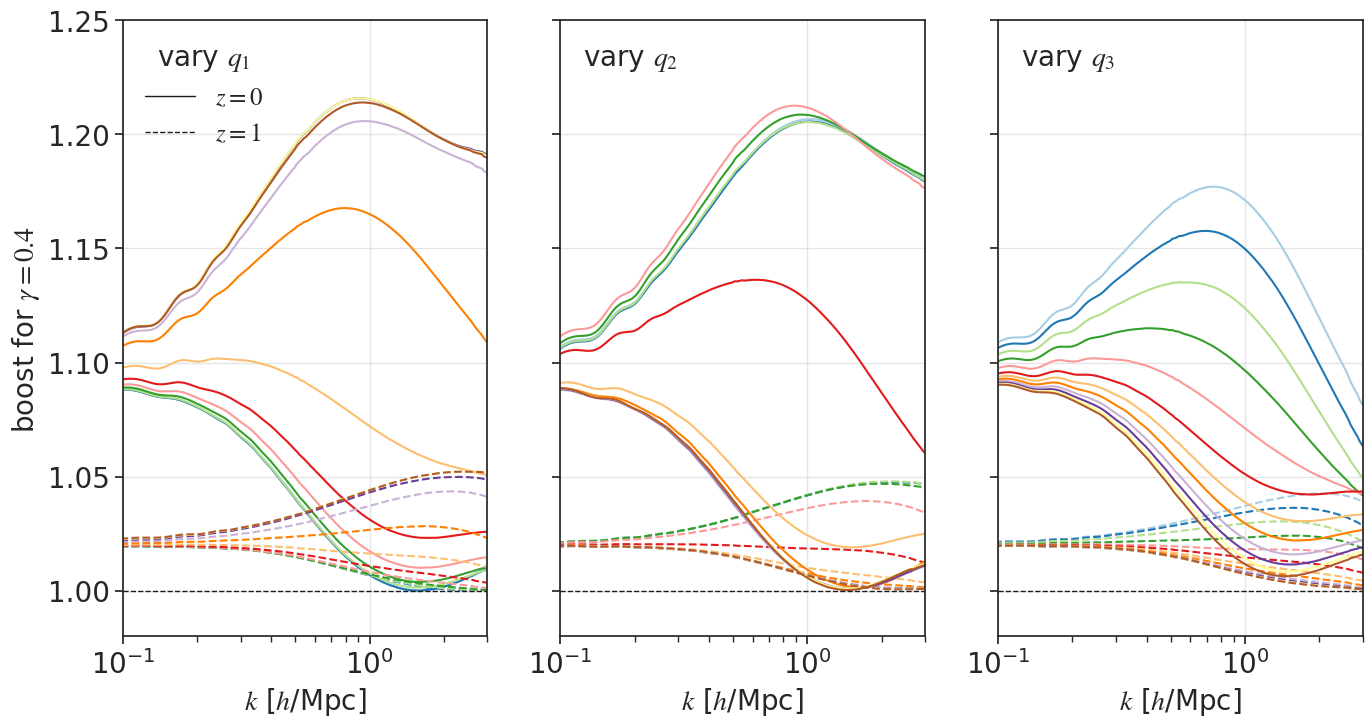

In [21]:
fig, ax = plt.subplots(1, 3, figsize=(16, 8), facecolor='w', sharex=True, sharey=True)
for j in range(len(q_arr)):    
    boost = mg_boost_q1q2q3(0.4, q_arr[j], 0., 0.)
    ax[0].semilogx(kh_nl_boost, boost[0], linewidth=1.5, color = colors[j], linestyle='-')
    ax[0].semilogx(kh_nl_boost, boost[1], linewidth=1.5, color = colors[j], linestyle='--')

    boost = mg_boost_q1q2q3(0.4, 0., q_arr[j], 0.)
    ax[1].semilogx(kh_nl_boost, boost[0], linewidth=1.5, color = colors[j], linestyle='-')
    ax[1].semilogx(kh_nl_boost, boost[1], linewidth=1.5, color = colors[j], linestyle='--')

    boost = mg_boost_q1q2q3(0.4, 0., 0., q_arr[j])
    ax[2].semilogx(kh_nl_boost, boost[0], linewidth=1.5, color = colors[j], linestyle='-')
    ax[2].semilogx(kh_nl_boost, boost[1], linewidth=1.5, color = colors[j], linestyle='--')
ax[0].axhline(y=0.5, color='k', linestyle='-', linewidth=1, label="$z=0$")    
ax[0].axhline(y=0.5, color='k', linestyle='--', linewidth=1, label="$z=1$")    
for i in range(3):    
    ax[i].legend(title='vary $q_'+str(i+1)+'$', loc='upper left', frameon=False, title_fontsize=20)
    ax[i].set_xlabel("$k$ [$h$/Mpc]")
    ax[i].grid(alpha=0.5)
    ax[i].grid(alpha=0.5)
    ax[i].set_ylim(0.98, 1.25)    
    ax[i].set_xlim(0.1, 3.)    
    ax[i].axhline(y=1.0, color='k', linestyle='--', linewidth=1)   
ax[0].set_ylabel("boost for $\gamma=0.4$")

Text(0, 0.5, 'boost for $f_{R0}$')

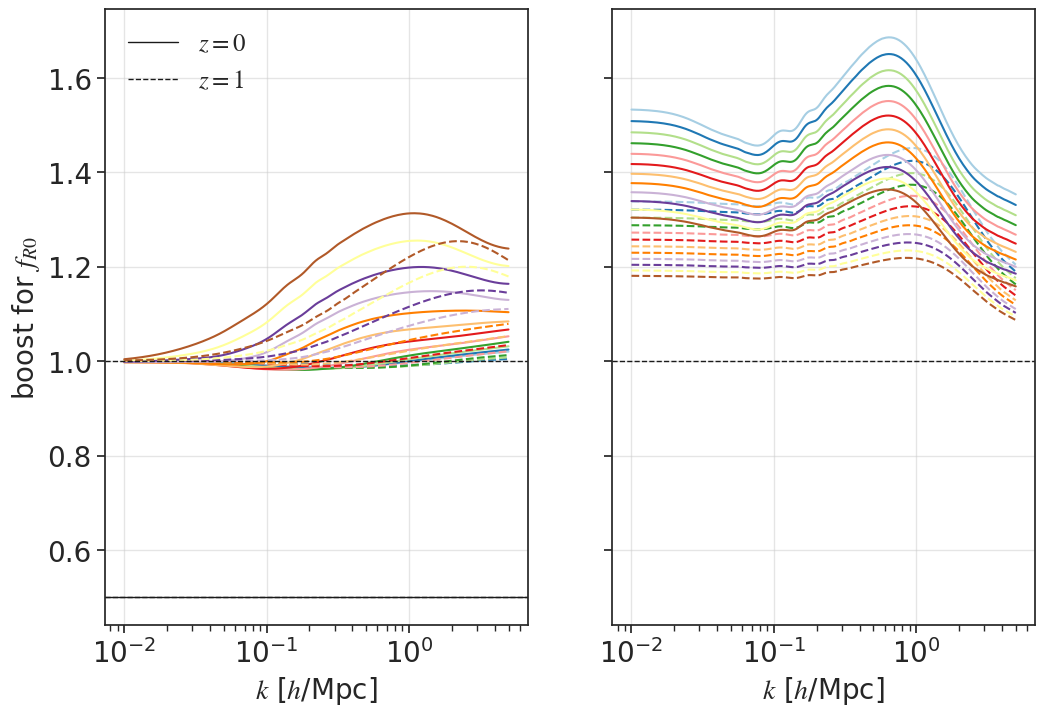

In [23]:
fR0_arr = np.logspace(-7, -4, 12)
omegarc_arr = np.logspace(1, 0.25, 12)
fig, ax = plt.subplots(1, 2, figsize=(12, 8), facecolor='w', sharex=True, sharey=True)
for j in range(len(fR0_arr)):    
    boost = mg_boost_fr(fR0_arr[j])
    ax[0].semilogx(kh_nl_boost, boost[0], linewidth=1.5, color = colors[j], linestyle='-')
    ax[0].semilogx(kh_nl_boost, boost[1], linewidth=1.5, color = colors[j], linestyle='--')

for j in range(len(omegarc_arr)):    
    boost = mg_boost_ndgp(omegarc_arr[j])
    ax[1].semilogx(kh_nl_boost, boost[0], linewidth=1.5, color = colors[j], linestyle='-')
    ax[1].semilogx(kh_nl_boost, boost[1], linewidth=1.5, color = colors[j], linestyle='--')

ax[0].axhline(y=0.5, color='k', linestyle='-', linewidth=1, label="$z=0$")    
ax[0].axhline(y=0.5, color='k', linestyle='--', linewidth=1, label="$z=1$")    
for i in range(2):    
    ax[i].legend(loc='upper left', frameon=False, title_fontsize=20)
    ax[i].set_xlabel("$k$ [$h$/Mpc]")
    ax[i].grid(alpha=0.5)
    ax[i].grid(alpha=0.5)
    #ax[i].set_ylim(0.98, 1.25)    
    #ax[i].set_xlim(0.1, 3.)    
    ax[i].axhline(y=1.0, color='k', linestyle='--', linewidth=1)   
ax[0].set_ylabel("boost for $f_{R0}$")